In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def make_synthetic_linear_regression(
    n: int = 600,
    d: int = 20,
    noise_std: float = 0.5,
    sparsity: float = 0.5,
):
    """Синтетическая линейная регрессия: y = X w_true + noise.
    sparsity: доля нулевых компонент в w_true (примерно).
    """
    X = np.random.randn(n, d).astype(np.float32)
    w_true = np.random.randn(d).astype(np.float32)
    k0 = int(d * sparsity)

    if k0 > 0:
        zero_idx = np.random.choice(d, size=k0, replace=False)
        w_true[zero_idx] = 0.0

    y = X @ w_true + noise_std * np.random.randn(n).astype(np.float32)
    return X, y, w_true

def train_val_test_split(X, y, train_ratio=0.6, val_ratio=0.2):
    n = len(X)
    idx = np.random.permutation(n)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train+n_val]
    test_idx = idx[n_train+n_val:]
    return (X[train_idx], y[train_idx]), (X[val_idx], y[val_idx]), (X[test_idx], y[test_idx])

def mse(pred, target):
    return torch.mean((pred - target) ** 2)

def l2_norm(w: torch.Tensor) -> float:
    return float(torch.norm(w.detach(), p=2).cpu().item())

def sparsity_ratio(w: torch.Tensor, eps: float = 0.01) -> float:
    w_abs = torch.abs(w.detach()).cpu().numpy()
    return float(np.mean(w_abs < eps))

def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=device)

X_np, y_np, w_true_np = make_synthetic_linear_regression(n=800, d=25, noise_std=0.7, sparsity=0.4)
(train_X, train_y), (val_X, val_y), (test_X, test_y) = train_val_test_split(X_np, y_np, 0.6, 0.2)

train_X_t, train_y_t = to_tensor(train_X), to_tensor(train_y).view(-1, 1)
val_X_t, val_y_t     = to_tensor(val_X),   to_tensor(val_y).view(-1, 1)
test_X_t, test_y_t   = to_tensor(test_X),  to_tensor(test_y).view(-1, 1)

w_true_t = to_tensor(w_true_np).view(-1, 1)

print("Shapes:", train_X_t.shape, train_y_t.shape, "| w_true:", w_true_t.shape)

Device: cpu
Shapes: torch.Size([480, 25]) torch.Size([480, 1]) | w_true: torch.Size([25, 1])


### L1- и L2-регуляризация вручную

In [ ]:
def compute_l1_regularization(w: torch.Tensor, lam: float):
    return lam / 2 * w.abs().sum()

def compute_l2_regularization(w, lam: float):
    return lam / 2 * (w ** 2).sum()

lamda = [0.01, 0.1, 0.5, 1.0]
tests = [
    torch.tensor([1.0, 5.0, 10.0]),
    torch.tensor([0.0, 0.5, -0.5]),
    torch.tensor([10.0, -10.0, 0.1]),
]

for w in tests:
    print(f"Регуляризация для тензора: {w}")
    for lam in lamda:
        l1 = compute_l1_regularization(w, lam)
        l2 = compute_l2_regularization(w, lam)

        print(
            f"Значения при лямбда={lam}\n"
            f"{l1=}\n"
            f"{l2=}\n"
        )


Регуляризация для тензора: tensor([ 1.,  5., 10.])
Значения при лямбда=0.01
l1=tensor(0.0800)
l2=tensor(0.6300)

Значения при лямбда=0.1
l1=tensor(0.8000)
l2=tensor(6.3000)

Значения при лямбда=0.5
l1=tensor(4.)
l2=tensor(31.5000)

Значения при лямбда=1.0
l1=tensor(8.)
l2=tensor(63.)

Регуляризация для тензора: tensor([ 0.0000,  0.5000, -0.5000])
Значения при лямбда=0.01
l1=tensor(0.0050)
l2=tensor(0.0025)

Значения при лямбда=0.1
l1=tensor(0.0500)
l2=tensor(0.0250)

Значения при лямбда=0.5
l1=tensor(0.2500)
l2=tensor(0.1250)

Значения при лямбда=1.0
l1=tensor(0.5000)
l2=tensor(0.2500)

Регуляризация для тензора: tensor([ 10.0000, -10.0000,   0.1000])
Значения при лямбда=0.01
l1=tensor(0.1005)
l2=tensor(1.0000)

Значения при лямбда=0.1
l1=tensor(1.0050)
l2=tensor(10.0005)

Значения при лямбда=0.5
l1=tensor(5.0250)
l2=tensor(50.0025)

Значения при лямбда=1.0
l1=tensor(10.0500)
l2=tensor(100.0050)



**ВЫВОД**  

- При увеличении параметра регуляризации `lambda`, значение регуляризатора растет линейно
- При увеличении нормы `w`:
  - для `l1-регуляризации` рост линейный; увеличение веса в два раза увеличивает штраф в два раза;
  - для `l2-резуляризации` рост квадратичный; увеличение веса в два раза увеличивает штраф в четыре раза;

### Обучение с L2-регуляризацией

In [3]:

class LinearRegressor(nn.Module):
    def __init__(self, d: int):
        super().__init__()
        self.fc1 = nn.Linear(d, 50)
        self.fc2 = nn.Linear(50, 10)
        self.fc3 = nn.Linear(10, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def compute_l2_regularization(params, lam: float):
    l2 = 0
    for param in params:
        l2 += (param ** 2).sum()
    return lam / 2 * l2

def train_linear_with_l2(
    lam: float,
    lr: float = 0.05,
    epochs: int = 800,
):
    model = LinearRegressor(train_X_t.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []
    for _ in range(epochs):
        optimizer.zero_grad()
        
        y_pred = model(train_X_t)
        mse_loss = mse(y_pred, train_y_t)
        l2_loss = compute_l2_regularization(model.parameters(), lam)
        
        loss = mse_loss + l2_loss
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())

    with torch.no_grad():
        y_pred_train = model(train_X_t)
        y_pred_val = model(val_X_t)
        y_pred_test = model(test_X_t)
        
        val_mse = float(mse(y_pred_val, val_y_t).item())
        test_mse = float(mse(y_pred_test, test_y_t).item())

        w_hat = model.fc3.weight.detach().squeeze().numpy()
    
    train_score = r2_score(train_y, y_pred_train)
    test_score = r2_score(test_y, y_pred_test)

    return {
        "model": model,
        "losses": losses,
        "val_mse": val_mse,
        "test_mse": test_mse,
        "weights": w_hat,
        "train_score": train_score,
        "test_score": test_score,
        "l1_norm": np.sum(np.abs(w_hat)),
        "l2_norm": np.linalg.norm(w_hat),
        "sparsity": np.mean(np.abs(w_hat) < 0.01),
    }

lambdas = [0.0, 0.01, 0.1, 1.0]

results = {}
for lam in lambdas:
    results[lam] = train_linear_with_l2(lam)


In [4]:

for lam in lambdas:
    print(
        f"При {lam=}:\n"
        f"MSE: {results[lam]["test_mse"]:.4f}\n"
        f"Качество на обучающей выборке: {results[lam]["train_score"]:.4f}\n"
        f"Качество на тестовой выборке: {results[lam]["test_score"]:.4f}\n"
    )

При lam=0.0:
MSE: 0.8626
Качество на обучающей выборке: 1.0000
Качество на тестовой выборке: 0.9433

При lam=0.01:
MSE: 0.7518
Качество на обучающей выборке: 0.9948
Качество на тестовой выборке: 0.9506

При lam=0.1:
MSE: 0.6637
Качество на обучающей выборке: 0.9891
Качество на тестовой выборке: 0.9564

При lam=1.0:
MSE: 1.6900
Качество на обучающей выборке: 0.9186
Качество на тестовой выборке: 0.8889



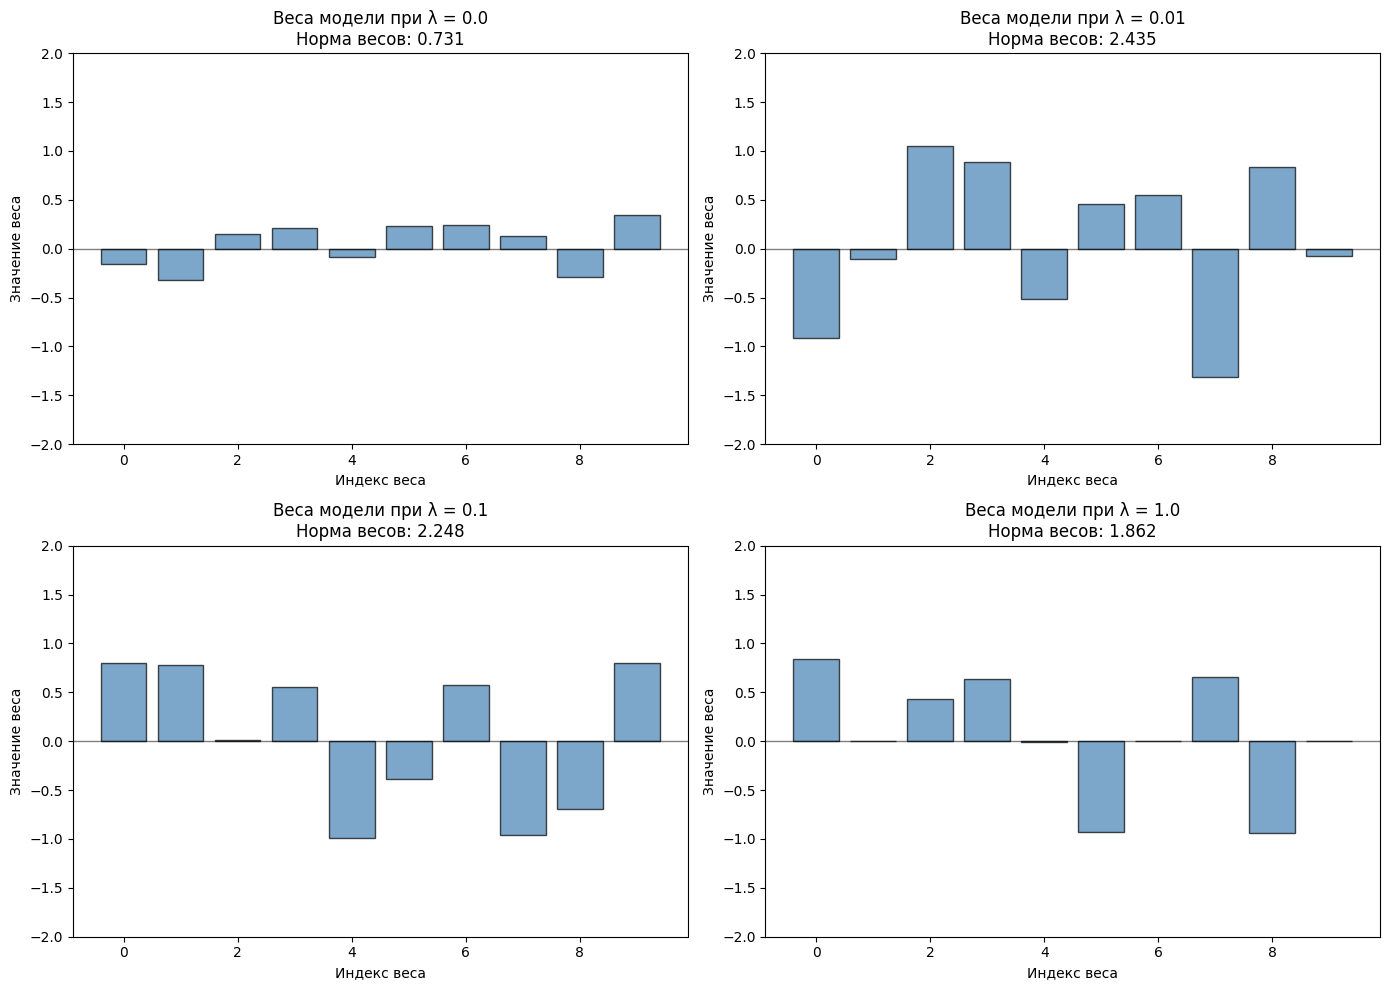

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, lam in enumerate(lambdas):
    ax = axes[idx]
    model = results[lam]["model"]
    weights = results[lam]["weights"]

    x_pos = np.arange(len(weights))
    ax.bar(x_pos, weights, alpha=0.7, color="steelblue", edgecolor="black")
    ax.axhline(y=0, color="black", linestyle="-", linewidth=1, alpha=0.5)

    ax.set_xlabel("Индекс веса", fontsize=10)
    ax.set_ylabel("Значение веса", fontsize=10)
    ax.set_title(
        f"Веса модели при λ = {lam}\n"
        f"Норма весов: {np.linalg.norm(weights):.3f}",
        fontsize=12,
    )
    ax.set_ylim(-2, 2)

plt.tight_layout()
plt.show()

**ВЫВОД**  

Без регуляризации модель склонна к переобучению, демонстрируя более низкую обобщающую способность на неизвестных данных. В то же время, слишком высокое значение параметра регуляризации так же ухудшают модель (появляется недообучение), зануляя важные веса. При показателе лямбда `0.1` значения весов распределены относительно равномерно, а разрыв между `R^2` на обучающей и тестовой выборке самый минимальный.

### Weight Decay в оптимизаторе PyTorch

In [ ]:
def train_linear_with_weight_decay(
    weight_decay: float,
    lr: float = 0.05,
    epochs: int = 600,
):
    model = LinearRegressor(train_X_t.shape[1]).to(device)
    opt = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses, val_losses = [], []
    for _ in range(epochs):
        model.train()
        opt.zero_grad()

        pred = model(train_X_t)
        loss = mse(pred, train_y_t)

        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            train_losses.append(float(loss.item()))
            val_losses.append(float(mse(model(val_X_t), val_y_t).item()))

    with torch.no_grad():
        test_loss = float(mse(model(test_X_t), test_y_t).item())
        w_hat = model.fc3.weight.detach().squeeze().numpy()

    return model, w_hat, train_losses, val_losses, test_loss

compare_lams = [0.0, 0.1, 1.0]
for lam in compare_lams:
    res_l2 = train_linear_with_l2(lam, lr=0.05, epochs=400)
    w_l2, test_l2 = res_l2["weights"], res_l2["test_mse"]
    
    _, w_wd, _, _, test_wd = train_linear_with_weight_decay(lam, lr=0.05, epochs=400)

    diff = np.linalg.norm(w_l2 - w_wd)
    
    print(f"λ={lam} | test_mse L2={test_l2:.4f} | test_mse WD={test_wd:.4f} | ||w_L2 - w_WD||2={diff:.4f}")

λ=0.0 | test_mse L2=0.9553 | test_mse WD=0.8191 | ||w_L2 - w_WD||2=2.5580
λ=0.1 | test_mse L2=0.6335 | test_mse WD=0.7255 | ||w_L2 - w_WD||2=3.1439
λ=1.0 | test_mse L2=1.7089 | test_mse WD=1.7023 | ||w_L2 - w_WD||2=2.9064


**ВЫВОД**  

- одинаковые значениях лямбда не приводят к идентичности результатов `l2-регуляризации` и `weight_decay`, итоговые веса моделей сильно отличаются
- лучший показатель достигается при использовании l2 со значением лямбда `0.1` `(MSE l2 | WD: 0.6335 | 0.7255)`
- высокий параметр регуляризации в обоих случаях ухудшает результат

### Early Stopping

In [7]:
class EarlyStopping:
    def __init__(
        self,
        patience: int = 10,
        min_delta: float = 1e-3,
        best_loss: float = np.inf,
    ) -> None:
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = best_loss
        self.counter = 0
        self.epoch = None
        self.best_state = None

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state = model.state_dict()
            self.counter = 0
            return False

        else:
            self.counter += 1
            return self.counter >= self.patience


def train_linear_with_weight_decay(
    weight_decay: float =  0.1,
    lr: float = 0.05,
    epochs: int = 600,
    with_stopping: bool = True,
):
    model = LinearRegressor(train_X_t.shape[1]).to(device)
    opt = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    early_stopping = EarlyStopping() if with_stopping else None

    result = {}
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        opt.zero_grad()

        pred = model(train_X_t)
        loss = mse(pred, train_y_t)

        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            train_losses.append(float(loss.item()))
            val_losses.append(float(mse(model(val_X_t), val_y_t).item()))
        
        if with_stopping and early_stopping(loss, model):
            result.update({
                "early_stopping": early_stopping,
                "stopped_epoch": epoch,
            })
            break

    result.update({
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
    })
    
    return result

with_stopping = train_linear_with_weight_decay()
without_stopping = train_linear_with_weight_decay(with_stopping=False)

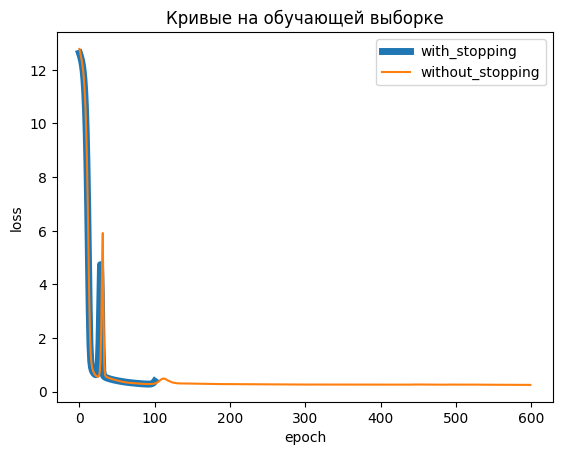

In [8]:
sns.lineplot(with_stopping["train_losses"], label="with_stopping", linewidth=5.0)
sns.lineplot(without_stopping["train_losses"], label="without_stopping")

plt.title("Кривые на обучающей выборке")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.show()

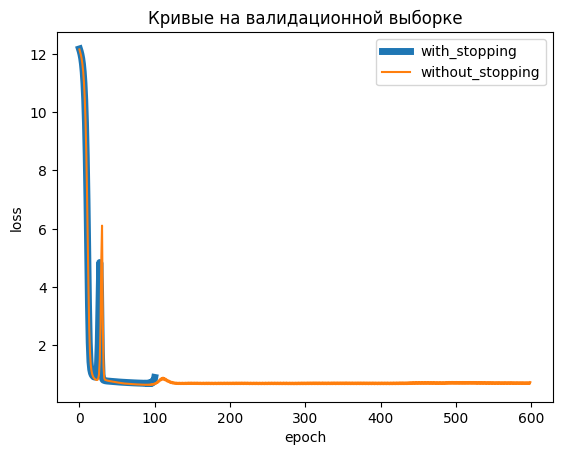

In [9]:
sns.lineplot(with_stopping["val_losses"], label="with_stopping", linewidth=5.0)
sns.lineplot(without_stopping["val_losses"], label="without_stopping")

plt.title("Кривые на валидационной выборке")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.show()

### Сравнение L1- и L2-регуляризации

In [10]:
def compute_l1_regularization(params, lam: float):
    l1_reg = 0
    for param in params:
        l1_reg += param.abs().sum()
    return lam / 2 * l1_reg

def train_linear_with_l1(
    lam: float,
    lr: float = 0.05,
    epochs: int = 800,
):
    model = LinearRegressor(train_X_t.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    
    for _ in range(epochs):
        model.train()   
        opt.zero_grad()

        y_pred = model(train_X_t)
        mse_loss = mse(y_pred, train_y_t)
        l1_loss = compute_l1_regularization(model.parameters(), lam)
        
        loss = mse_loss + l1_loss
        loss.backward()
        opt.step()

        model.eval()

    with torch.no_grad():
        y_pred_val = model(val_X_t)
        y_pred_test = model(test_X_t)
        
        val_mse = float(mse(y_pred_val, val_y_t).item())
        test_mse = float(mse(y_pred_test, test_y_t).item())

        w_hat = model.fc3.weight.detach().squeeze().numpy()

    return {
        "model": model,
        "val_mse": val_mse,
        "test_mse": test_mse,
        "weights": w_hat,
        "l1_norm": np.sum(np.abs(w_hat)),
        "l2_norm": np.linalg.norm(w_hat),
        "sparsity": np.mean(np.abs(w_hat) < 0.01),
    }

lam = 0.1
l1 = train_linear_with_l1(lam, lr=0.05, epochs=900)
l2 = train_linear_with_l2(lam, lr=0.05, epochs=900)

In [11]:
results = [
    {"name": "L1", **l1},
    {"name": "L2", **l2},
]

df = pd.DataFrame(results)[[
    "name", "val_mse", "test_mse",
    "l1_norm", "l2_norm", "sparsity",
]]

df

,name,val_mse,test_mse,l1_norm,l2_norm,sparsity
0,L1,0.575125,0.485560,4.452194,3.127395,0.8
1,L2,0.679949,0.684203,6.607032,2.243055,0.1


**ВЫВОД**  

- l1-регуляризация обнуляет веса `(sparsity=0.8)`, производя самостоятельный отбор признаков; имеет меньшую l1-норму `(l1_norm=4.45)`
- l2-регуляризация сглаживает веса, но не стремится их "занулить" `(sparsity=0.1)`; имеет меньшую l2-норму `(l2_norm=2.24)`

Для полученных данных, использование l1-регуляризации позволяет получить более низку ошибку, чем при l2 `(test_mse l1 | l2: 0.49 | 0.68)`

### Эксперимент с λ

In [12]:
lambdas = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]
val_losses = []
test_losses = []
norms = []

for lam in lambdas:
    res = train_linear_with_l2(lam)
    val_losses.append(round(res["val_mse"], 4))
    test_losses.append(round(res["test_mse"], 4))
    norms.append(round(res["l2_norm"], 4))

df = pd.DataFrame({
    "lambda": lambdas,
    "val_mse": val_losses,
    "test_mse": test_losses,
    "l2_norm": norms,
})

df["lambda_log10"] = np.log10(df["lambda"] + 1e-10)

display(df)

,lambda,val_mse,test_mse,l2_norm,lambda_log10
0,0.0000,1.0042,0.7794,0.6507,-1.000000e+01
1,0.0001,0.8198,0.8687,0.9815,-4.000000e+00
2,0.0010,0.7943,0.7278,1.4024,-3.000000e+00
3,0.0100,0.7845,0.6902,2.3808,-2.000000e+00
4,0.1000,0.6818,0.6663,2.2578,-1.000000e+00
5,1.0000,1.1139,1.7059,1.8606,4.342945e-11
6,10.0000,12.2689,15.2788,0.0000,1.000000e+00


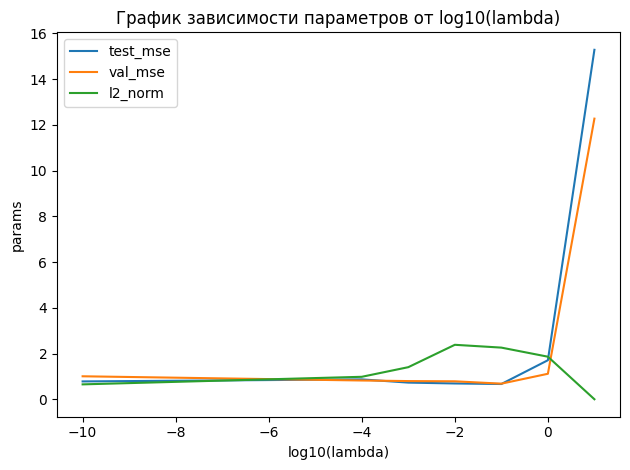

In [13]:
sns.lineplot(x=df["lambda_log10"], y=df["test_mse"], label="test_mse")
sns.lineplot(x=df["lambda_log10"], y=df["val_mse"], label="val_mse")
sns.lineplot(x=df["lambda_log10"], y=df["l2_norm"], label="l2_norm")

plt.title("График зависимости параметров от log10(lambda)")
plt.xlabel("log10(lambda)")
plt.ylabel("params")

plt.tight_layout()
plt.show()

**ВЫВОД**  

- при `lambda < 0.01` модель недообучается, высокая ошибка как на обучении, так и на валидации, низкая l2-норма говорит о слишком простой модели
- при `0.01 <= lambda <=0.1` модель достигает наилучшего баланса между смещением и дисперсией, l2-норма максимальна, а MSE минимальна
- при `lambda > 1` модель начинает переобучаться или вовсе перестаёт работать, что приводит к кратному увеличению ошибки, а l2-норма падает до нуля

### Визуализация кривых обучения

In [ ]:

def train_linear(
    lr: float = 0.05,
    lam: float = 0.1,
    epochs: int = 600,
    with_stopping: bool = False,
    l1_reg: bool = False,
    l2_reg: bool = False,
):
    model = LinearRegressor(train_X_t.shape[1]).to(device)
    opt = optim.SGD(model.parameters(), lr=lr)
    early_stopping = EarlyStopping() if with_stopping else None

    result = {}
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        opt.zero_grad()

        pred = model(train_X_t)
        loss = mse(pred, train_y_t)
        
        if l1_reg:
            loss += compute_l1_regularization(model.parameters(), lam)
        
        if l2_reg:
            loss += compute_l2_regularization(model.parameters(), lam)

        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            train_losses.append(float(loss.item()))
            val_loss = float(mse(model(val_X_t), val_y_t).item())
            val_losses.append(val_loss)
        
        if with_stopping and early_stopping(val_loss, model):
            result.update({
                "early_stopping": early_stopping,
                "stopped_epoch": epoch,
            })
            break

    with torch.no_grad():
        y_pred_val = model(val_X_t)
        y_pred_test = model(test_X_t)
        
        val_mse = float(mse(y_pred_val, val_y_t).item())
        test_mse = float(mse(y_pred_test, test_y_t).item())

        w_hat = model.fc3.weight.detach().squeeze().numpy()

    result.update({
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_mse": val_mse,
        "test_mse": test_mse,
        "weights": w_hat,
        "l1_norm": np.sum(np.abs(w_hat)),
        "l2_norm": np.linalg.norm(w_hat),
        "sparsity": np.mean(np.abs(w_hat) < 0.01),
    })

    return result

without_reg = train_linear()

l1_reg = train_linear(l1_reg=True)

l2_reg = train_linear(l2_reg=True)

early_stopping = train_linear(with_stopping=True)


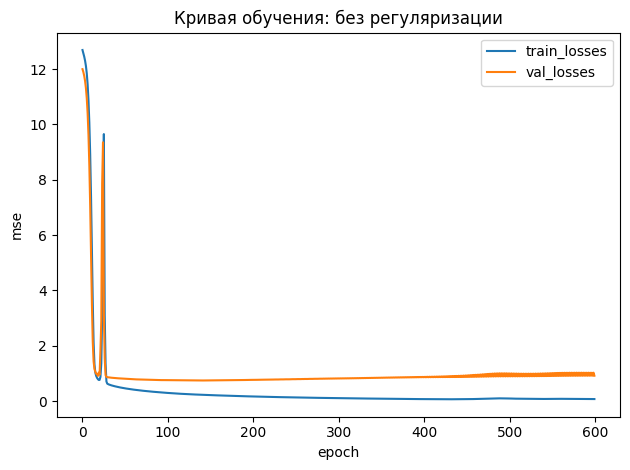

In [15]:
sns.lineplot(without_reg["train_losses"], label="train_losses")
sns.lineplot(without_reg["val_losses"], label="val_losses")

plt.title("Кривая обучения: без регуляризации")
plt.xlabel("epoch")
plt.ylabel("mse")

plt.tight_layout()
plt.show()

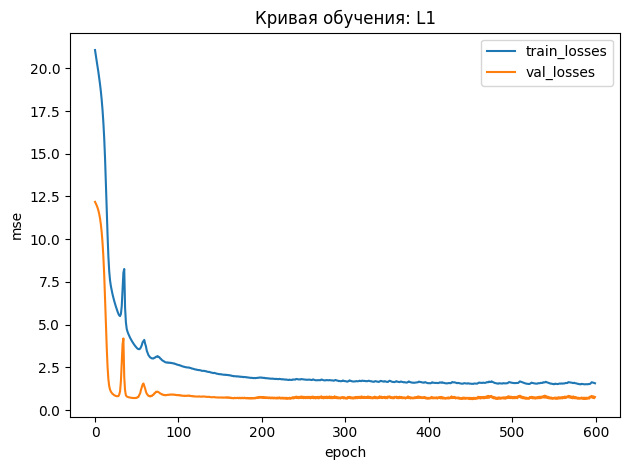

In [16]:
sns.lineplot(l1_reg["train_losses"], label="train_losses")
sns.lineplot(l1_reg["val_losses"], label="val_losses")

plt.title("Кривая обучения: L1")
plt.xlabel("epoch")
plt.ylabel("mse")

plt.tight_layout()
plt.show()

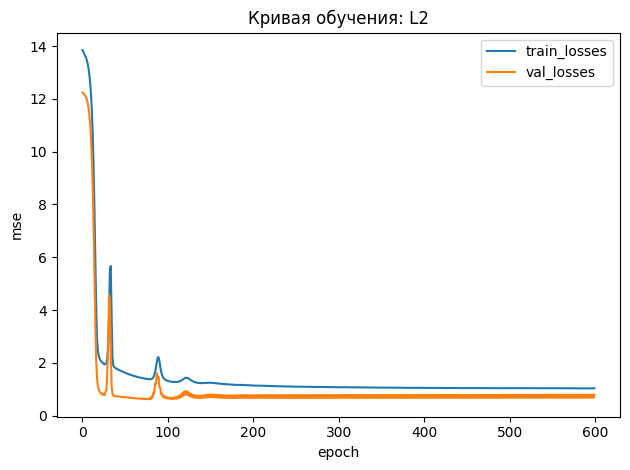

In [17]:
sns.lineplot(l2_reg["train_losses"], label="train_losses")
sns.lineplot(l2_reg["val_losses"], label="val_losses")

plt.title("Кривая обучения: L2")
plt.xlabel("epoch")
plt.ylabel("mse")

plt.tight_layout()
plt.show()

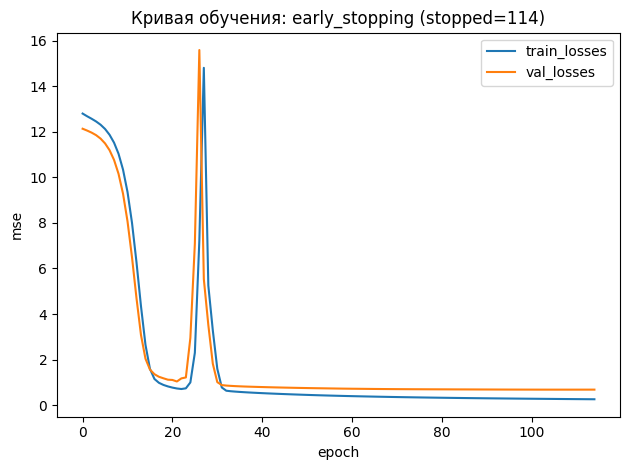

In [18]:
stopped = early_stopping.pop("stopped_epoch")

sns.lineplot(early_stopping["train_losses"], label="train_losses")
sns.lineplot(early_stopping["val_losses"], label="val_losses")

plt.title(f"Кривая обучения: early_stopping (stopped={stopped})")
plt.xlabel("epoch")
plt.ylabel("mse")

plt.tight_layout()
plt.show()

**ВЫВОД**  

У моделей без какой-либо регуляризации видны признаки переобучения: при снижении `train_losses` возрастает `val_losses`, модель заучивает обучающую выборку. В то же время, модели с регуляризацией показывают более плавное и близкое изменение этих показателей - расстояние между линиями очень низкое, модель лучше обобщает.

### Оценка предсказания и неопределенность регрессионной нейросети с Dropout. Monte Carlo Dropout

In [19]:
def make_1d_regression(n=250, noise=0.15):
    X = np.random.uniform(-1, 1, n)
    y = np.sin(np.pi * X) + noise * np.random.randn(n)

    return X, y

X1, y1 = make_1d_regression()

(train_X, train_y), (val_X, val_y), (test_X, test_y) = train_val_test_split(X1, y1, 0.6, 0.2)

train_X_t1, train_y_t1 = to_tensor(train_X).view(-1, 1), to_tensor(train_y).view(-1, 1)
val_X_t1, val_y_t1 = to_tensor(val_X).view(-1, 1), to_tensor(val_y).view(-1, 1)
test_X_t1, test_y_t1 = to_tensor(test_X).view(-1, 1), to_tensor(test_y).view(-1, 1)

class MLPDropout(nn.Module):
    def __init__(self, p: float = 0.2):
        super().__init__()
        self.fc1 = nn.Linear(1, 64)
        self.dropout1 = nn.Dropout(p)
        self.fc2 = nn.Linear(64, 32)
        self.dropout2 = nn.Dropout(p)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        
        return x

def train_mlp(model: nn.Module, lr=1e-3, epochs=1500):
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        
        y_pred = model(train_X_t1)
        loss = mse(y_pred, train_y_t1)
        
        loss.backward()
        opt.step()
        
        model.eval()
        with torch.no_grad():
            train_losses.append(loss.item())
            val_pred = model(val_X_t1)
            val_loss = mse(val_pred, val_y_t1).item()
            val_losses.append(val_loss)

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
    }

def mc_dropout_predict(
    model: nn.Module,
    X: torch.Tensor,
    n_samples: int = 50,
):
    """Возвращает mean и std предсказаний при включенном Dropout."""
    model.train()

    preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            y_pred = model(X)
            preds.append(y_pred)

    preds = torch.stack(preds, dim=0)

    mean = preds.mean(dim=0)
    std = preds.std(dim=0)

    return mean, std

mlp = MLPDropout(p=0.25).to(device)
mlp = train_mlp(mlp)

grid = torch.linspace(-2.5, 2.5, 500).reshape(-1, 1).to(device)

mean_pred, std_pred = mc_dropout_predict(
    model=mlp["model"],
    X=grid,
)

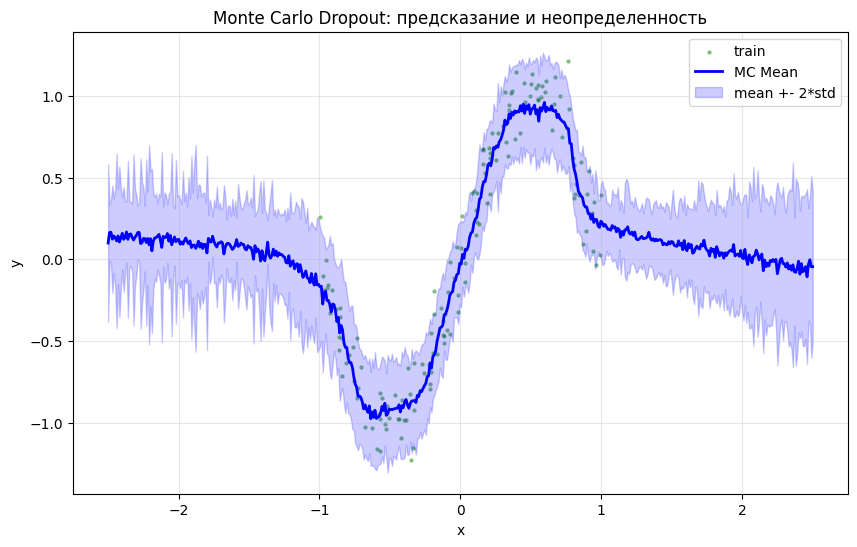

In [20]:
x_grid = grid.cpu().numpy().flatten()
y_mean = mean_pred.cpu().numpy().flatten()
y_std = std_pred.cpu().numpy().flatten()

train_x_np = train_X_t1.numpy().flatten()
train_y_np = train_y_t1.numpy().flatten()

df_mean = pd.DataFrame({
    "x": x_grid,
    "y": y_mean,
    "type": "MCD"
})

df_train = pd.DataFrame({
    "x": train_x_np,
    "y": train_y_np,
    "type": "Обучающие данные"
})

df_plot = pd.concat([df_mean, df_train], ignore_index=True)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=train_x_np,
    y=train_y_np,
    color="green",
    s=10,
    alpha=0.5,
    label="train",
)

sns.lineplot(
    x=x_grid,
    y=y_mean,
    color="blue",
    linewidth=2,
    label="MC Mean",
)

plt.fill_between(
    x_grid,
    y_mean - 2*y_std,
    y_mean + 2*y_std, 
    alpha=0.2,
    color="blue",
    label="mean +- 2*std",
)


plt.title("Monte Carlo Dropout: предсказание и неопределенность")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

**ВЫВОД**  

Модель наиболее уверена в областях, где есть обучающие данные (`x=+-1`), и наименее уверена на краях и за пределами обучающей выборки (`x>1 and x<-1`).

### Обобщающее сравнение

In [ ]:
def train_linear_elastic_net(
    lam: float = 0.1,
    alpha: float = 0.5,
    lr: float = 0.05,
    epochs: int = 900,
):
    model = LinearRegressor(train_X_t.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    result = {}
    train_losses, val_losses = [], []
    for _ in range(epochs):
        model.train()
        opt.zero_grad()

        pred = model(train_X_t)
        loss = mse(pred, train_y_t)
        
        l1_reg = compute_l1_regularization(model.parameters(), lam)
        l2_reg = compute_l2_regularization(model.parameters(), lam)

        loss += alpha * l1_reg + (1 - alpha) * l2_reg

        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            train_losses.append(float(loss.item()))
            val_loss = float(mse(model(val_X_t), val_y_t).item())
            val_losses.append(val_loss)

    with torch.no_grad():
        y_pred_val = model(val_X_t)
        y_pred_test = model(test_X_t)
        
        val_mse = float(mse(y_pred_val, val_y_t).item())
        test_mse = float(mse(y_pred_test, test_y_t).item())

        w_hat = model.fc3.weight.detach().squeeze().numpy()

    result.update({
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_mse": val_mse,
        "test_mse": test_mse,
        "weights": w_hat,
        "l1_norm": np.sum(np.abs(w_hat)),
        "l2_norm": np.linalg.norm(w_hat),
        "sparsity": np.mean(np.abs(w_hat) < 0.01),
    })

    return result

without_reg = train_linear()

l2_reg = train_linear(l2_reg=True)

l1_reg = train_linear(l1_reg=True)

elastic_net = train_linear_elastic_net()

early_stopping = train_linear(with_stopping=True)

In [22]:
results = [
    {"name": "without_reg", **without_reg},
    {"name": "l1_reg", **l1_reg},
    {"name": "l2_reg", **l2_reg},
    {"name": "elastic_net", **elastic_net},
    {"name": "early_stopping", **early_stopping},
]

df = pd.DataFrame(results)[["name", "test_mse", "l2_norm", "sparsity"]]

df

,name,test_mse,l2_norm,sparsity
0,without_reg,0.784890,2.396956,0.0
1,l1_reg,0.536710,2.913839,0.6
2,l2_reg,0.712507,2.179296,0.1
3,elastic_net,0.502821,2.343356,0.7
4,early_stopping,0.726258,1.928180,0.0


**ВЫВОД**  

`ElasticNet` показал лучшее качество (минимальная ошибка на тесте `0.5`); обнулил порядка `70% весов`, оставив только самые важные признаки, тем самым улучшив интерпретируемость модели; подбирая параметр `alpha` и смещая баланс между `l1` и `l2` регуляризациями, можно лучше учитывать выбросы, модель более устойчива.